# Notebook 04 — Modelo 3: Transformer encoder

**TFM · Máster en Inteligencia Artificial · Manuel Montilla Luna**

**Predicción de Vida Útil Restante (RUL) sobre NASA C-MAPSS**

En esta tercera arquitectura se prescinde por completo de componentes
recurrentes y convolucionales, basándose exclusivamente en autoatención multi-cabeza.

Su inclusión responde a un objetivo de contraste empírico. Las arquitecturas Transformer han
desplazado a las recurrentes en dominios como el procesamiento del lenguaje natural, pero su
ventaja depende de dos condiciones que aquí no se cumplen con claridad: grandes volúmenes de
datos y dependencias de largo alcance.

## 1. Configuración del entorno

In [1]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive")

# Ajusta esta ruta si subes el proyecto a otra carpeta de tu Drive
PROJECT_DIR = Path("/content/drive/MyDrive/ColabNotebooks/tfm")
DATA_DIR    = PROJECT_DIR / "data" / "CMAPSSData"
FIG_DIR     = PROJECT_DIR / "reports" / "figures"
MODELS_DIR  = PROJECT_DIR / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Proyecto : {PROJECT_DIR}")
print(f"Datos    : {DATA_DIR}   (existe: {DATA_DIR.exists()})")

Mounted at /content/drive
Proyecto : /content/drive/MyDrive/ColabNotebooks/tfm
Datos    : /content/drive/MyDrive/ColabNotebooks/tfm/data/CMAPSSData   (existe: True)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
import keras
from keras import layers

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 23
np.random.seed(RANDOM_STATE)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")

gpus = tf.config.list_physical_devices("GPU")
print(f"GPU        : {gpus if gpus else 'NO DISPONIBLE - el entrenamiento sera lento'}")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Hiperparámetros del experimento

Los parámetros de datos son idénticos a los de los notebooks 02 y 03.

Dos observaciones sobre los parámetros de entrenamiento. La tasa de aprendizaje es inferior
a la de los modelos anteriores, porque los Transformer son notablemente más sensibles a este
parámetro y una tasa alta provoca divergencia con frecuencia. Y el número de épocas es mayor,
porque al carecer del sesgo inductivo de recurrencia y convolución, esta arquitectura necesita
más iteraciones para converger.

In [3]:
# --- Parámetros de datos (idénticos a los notebooks 02 y 03) ---
SUBSET        = "FD001"
WINDOW        = 30
STRIDE        = 1
RUL_CAP       = 125
VAL_FRAC      = 0.20

# --- Parámetros de entrenamiento ---
EPOCHS        = 150      # más épocas: converge más despacio
BATCH_SIZE    = 256
LEARNING_RATE = 5e-4     # más baja: los Transformer son sensibles a este parámetro

# --- Parámetros de la arquitectura ---
D_MODEL       = 64       # dimensión del espacio de representación interno
NUM_HEADS     = 4        # cabezas de atención
DFF           = 128      # dimensión de la capa oculta del bloque feed-forward
NUM_BLOCKS    = 2        # bloques de codificador apilados
DROPOUT       = 0.1
DENSE_UNITS   = 64

## 3. Esquema de datos y funciones de carga

In [4]:
# --- Esquema de columnas de C-MAPSS ---------------------------------------
# Los ficheros no traen cabecera. Las 26 columnas son, en orden:
#   unit, cycle, setting_1..3, sensor_1..21

INDEX_COLS   = ["unit", "cycle"]
SETTING_COLS = ["setting_1", "setting_2", "setting_3"]
SENSOR_COLS  = [f"sensor_{i}" for i in range(1, 22)]
ALL_COLS     = INDEX_COLS + SETTING_COLS + SENSOR_COLS

SUBSETS = ("FD001", "FD002", "FD003", "FD004")

N_CONDITIONS  = {"FD001": 1, "FD002": 6, "FD003": 1, "FD004": 6}
N_FAULT_MODES = {"FD001": 1, "FD002": 1, "FD003": 2, "FD004": 2}


@dataclass
class CMAPSSSubset:
    """Contenedor de un subset completo de C-MAPSS."""

    name: str
    train: pd.DataFrame
    test: pd.DataFrame
    rul_test: pd.Series

    @property
    def n_conditions(self):
        return N_CONDITIONS[self.name]

    @property
    def n_fault_modes(self):
        return N_FAULT_MODES[self.name]

    def summary(self):
        return pd.Series({
            "subset": self.name,
            "condiciones_operativas": self.n_conditions,
            "modos_de_fallo": self.n_fault_modes,
            "motores_train": self.train["unit"].nunique(),
            "motores_test": self.test["unit"].nunique(),
            "filas_train": len(self.train),
            "filas_test": len(self.test),
        })

In [5]:
def _read_cmapss_file(path):
    """
    Lee un fichero train_FD00X.txt o test_FD00X.txt.

    Los ficheros originales terminan cada linea con dos espacios. Con
    `sep=" "` pandas generaria dos columnas fantasma llenas de NaN; usando la
    expresion regular `\s+` como separador el problema desaparece.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No se encuentra {path}.")

    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
    if df.shape[1] != len(ALL_COLS):
        raise ValueError(
            f"{path.name}: se esperaban {len(ALL_COLS)} columnas y se han leido "
            f"{df.shape[1]}.")

    df.columns = ALL_COLS
    return df.astype({"unit": "int32", "cycle": "int32"})


def _read_rul_file(path):
    """Lee RUL_FD00X.txt: una linea por motor de test con su RUL real."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No se encuentra {path}.")

    rul = pd.read_csv(path, sep=r"\s+", header=None, engine="python").iloc[:, 0]
    rul.name = "RUL"
    rul.index = range(1, len(rul) + 1)
    return rul.astype("int32")


def load_subset(name, data_dir=None):
    """Carga un subset completo: train + test + RUL de test."""
    name = name.upper()
    if name not in SUBSETS:
        raise ValueError(f"Subset desconocido: {name}. Opciones: {SUBSETS}")

    data_dir = Path(data_dir if data_dir is not None else DATA_DIR)
    return CMAPSSSubset(
        name=name,
        train=_read_cmapss_file(data_dir / f"train_{name}.txt"),
        test=_read_cmapss_file(data_dir / f"test_{name}.txt"),
        rul_test=_read_rul_file(data_dir / f"RUL_{name}.txt"),
    )

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_499/1065177080.py:7: SyntaxWarning: invalid escape sequence '\s'
  expresion regular `\s+` como separador el problema desaparece.


## 4. Preprocesado

Pipeline idéntico al de los notebooks 02 y 03.

In [6]:
def add_rul_train(df, rul_cap=125):
    """
    RUL del conjunto de entrenamiento: ultimo_ciclo - ciclo_actual, con tope.

    El tope produce el perfil de degradacion lineal a trozos. Su justificacion
    es que un motor nuevo no se degrada de forma apreciable: exigir al modelo
    que distinga entre 300 y 290 ciclos restantes no tiene reflejo fisico.
    """
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    if rul_cap is not None:
        df["RUL"] = df["RUL"].clip(upper=rul_cap)
    return df


def add_rul_test(df, rul_test, rul_cap=125):
    """RUL del conjunto de test, sumando el remanente de RUL_FD00X.txt."""
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    remaining = df["unit"].map(rul_test)
    df["RUL"] = (max_cycle - df["cycle"]) + remaining
    if rul_cap is not None:
        df["RUL"] = df["RUL"].clip(upper=rul_cap)
    return df


def fit_regime_clusterer(train, n_conditions):
    """K-Means sobre las variables de ajuste. None si solo hay un regimen."""
    if n_conditions <= 1:
        return None
    km = KMeans(n_clusters=n_conditions, random_state=RANDOM_STATE, n_init=10)
    km.fit(train[SETTING_COLS].values)
    return km


def assign_regime(df, clusterer):
    """Indice de regimen de cada fila (0 si solo hay un regimen)."""
    if clusterer is None:
        return np.zeros(len(df), dtype=int)
    return clusterer.predict(df[SETTING_COLS].values)


def fit_regime_scalers(train, regimes, feature_cols):
    """Un MinMaxScaler independiente por regimen, ajustado solo con train."""
    scalers = {}
    for r in np.unique(regimes):
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(train.loc[regimes == r, feature_cols].values)
        scalers[int(r)] = scaler
    return scalers


def apply_regime_scalers(df, regimes, scalers, feature_cols):
    """Aplica a cada fila el escalador de su regimen."""
    df = df.copy()
    values = df[feature_cols].values.astype(np.float64)
    out = np.empty_like(values)
    for r, scaler in scalers.items():
        mask = regimes == r
        if mask.any():
            out[mask] = scaler.transform(values[mask])
    df[feature_cols] = out
    return df


def find_uninformative_sensors(train, regimes=None, threshold=1e-6):
    """
    Sensores sin varianza informativa.

    El calculo debe hacerse DENTRO de cada regimen: en FD002/FD004 varios
    sensores son constantes dentro de cada regimen de vuelo pero toman valores
    distintos entre regimenes, de modo que medidos globalmente pareceria que
    aportan informacion cuando solo codifican el regimen.
    """
    if regimes is None:
        stds = train[SENSOR_COLS].std()
    else:
        per_regime = [train.loc[regimes == r, SENSOR_COLS].std()
                      for r in np.unique(regimes)]
        stds = pd.concat(per_regime, axis=1).max(axis=1)
    return sorted(stds[stds < threshold].index.tolist(),
                  key=lambda c: int(c.split("_")[1]))


def make_windows_train(df, feature_cols, window=30, stride=1):
    """Ventanas deslizantes de train. El target es el RUL del ultimo ciclo."""
    X_list, y_list, unit_list = [], [], []
    for unit, group in df.groupby("unit", sort=True):
        group = group.sort_values("cycle")
        feats = group[feature_cols].values.astype(np.float32)
        target = group["RUL"].values.astype(np.float32)
        if len(group) < window:
            continue
        for start in range(0, len(group) - window + 1, stride):
            end = start + window
            X_list.append(feats[start:end])
            y_list.append(target[end - 1])
            unit_list.append(unit)
    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(y_list, dtype=np.float32),
            np.asarray(unit_list, dtype=np.int32))


def make_windows_test(df, feature_cols, window=30):
    """
    Una ventana por motor de test: la ultima disponible.

    Motores mas cortos que la ventana: padding por repeticion del primer ciclo,
    preferible a descartarlos para no sesgar la evaluacion hacia casos faciles.
    """
    X_list, unit_list = [], []
    for unit, group in df.groupby("unit", sort=True):
        group = group.sort_values("cycle")
        feats = group[feature_cols].values.astype(np.float32)
        if len(feats) < window:
            pad = np.repeat(feats[:1], window - len(feats), axis=0)
            feats = np.vstack([pad, feats])
        X_list.append(feats[-window:])
        unit_list.append(unit)
    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(unit_list, dtype=np.int32))


def split_by_unit(X, y, units, val_frac=0.2):
    """
    Validacion reservando motores COMPLETOS.

    Un split por filas dejaria ventanas solapadas casi identicas a ambos lados
    y produciria metricas de validacion optimistas.
    """
    rng = np.random.default_rng(RANDOM_STATE)
    unique_units = np.unique(units)
    rng.shuffle(unique_units)
    n_val = max(1, int(round(len(unique_units) * val_frac)))
    val_units = set(unique_units[:n_val].tolist())
    val_mask = np.isin(units, list(val_units))
    return X[~val_mask], y[~val_mask], X[val_mask], y[val_mask]


@dataclass
class PreparedData:
    """Resultado del pipeline completo, listo para alimentar a Keras."""

    subset: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    test_units: np.ndarray
    feature_cols: list
    dropped_sensors: list
    window: int = 30
    rul_cap: int = 125

    @property
    def n_features(self):
        return len(self.feature_cols)

    def report(self):
        return (f"[{self.subset}] ventana={self.window}  features={self.n_features}  "
                f"cap RUL={self.rul_cap}\n"
                f"  sensores descartados : {len(self.dropped_sensors)}\n"
                f"  X_train : {self.X_train.shape}\n"
                f"  X_val   : {self.X_val.shape}\n"
                f"  X_test  : {self.X_test.shape}")


def prepare(subset, window=30, stride=1, rul_cap=125, val_frac=0.2,
            use_settings=False):
    """Pipeline completo de preprocesado sobre un subset."""
    train = add_rul_train(subset.train, rul_cap=rul_cap)
    test  = add_rul_test(subset.test, subset.rul_test, rul_cap=rul_cap)

    # Regimenes ANTES de la seleccion de variables
    clusterer     = fit_regime_clusterer(train, subset.n_conditions)
    train_regimes = assign_regime(train, clusterer)
    test_regimes  = assign_regime(test, clusterer)

    dropped      = find_uninformative_sensors(train, regimes=train_regimes)
    sensor_cols  = [c for c in SENSOR_COLS if c not in dropped]
    feature_cols = sensor_cols + (SETTING_COLS if use_settings else [])

    # Escaladores ajustados SOLO con train
    scalers = fit_regime_scalers(train, train_regimes, feature_cols)
    train   = apply_regime_scalers(train, train_regimes, scalers, feature_cols)
    test    = apply_regime_scalers(test, test_regimes, scalers, feature_cols)

    X, y, units = make_windows_train(train, feature_cols, window=window, stride=stride)
    X_train, y_train, X_val, y_val = split_by_unit(X, y, units, val_frac=val_frac)

    X_test, test_units = make_windows_test(test, feature_cols, window=window)
    y_test = subset.rul_test.reindex(test_units).values.astype(np.float32)
    if rul_cap is not None:
        y_test = np.clip(y_test, None, rul_cap)

    return PreparedData(
        subset=subset.name, X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
        test_units=test_units, feature_cols=feature_cols,
        dropped_sensors=dropped, window=window, rul_cap=rul_cap)

## 5. Métricas de evaluación

In [7]:
def rmse(y_true, y_pred):
    """Raiz del error cuadratico medio."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def mae(y_true, y_pred):
    """Error absoluto medio."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    return float(np.mean(np.abs(y_pred - y_true)))


def nasa_score(y_true, y_pred):
    """
    Funcion de puntuacion asimetrica de NASA (PHM 2008). Menor es mejor.

    Penaliza mas la sobreestimacion que la subestimacion del RUL: predecir que
    a un motor le quedan mas ciclos de los reales implica que la intervencion
    de mantenimiento llega tarde, con riesgo de fallo en servicio.
    """
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return float(np.sum(s))


def evaluate(y_true, y_pred, name="modelo"):
    """Bloque completo de metricas de un modelo."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    d = y_pred - y_true
    return pd.Series({
        "modelo": name,
        "RMSE": round(rmse(y_true, y_pred), 3),
        "MAE": round(mae(y_true, y_pred), 3),
        "NASA_Score": round(nasa_score(y_true, y_pred), 1),
        "sesgo_medio": round(float(np.mean(d)), 3),
        "pct_retrasadas": round(float(np.mean(d > 0) * 100), 1),
    })


def comparison_table(results):
    """Tabla comparativa ordenada por RMSE."""
    return pd.DataFrame(results).set_index("modelo").sort_values("RMSE")


def default_callbacks(checkpoint_path=None, patience=15, reduce_lr_patience=7):
    """
    Callbacks usados en todos los entrenamientos.

    EarlyStopping con restore_best_weights garantiza que el modelo evaluado sea
    el de mejor validacion, no el de la ultima epoca.
    """
    cbs = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=reduce_lr_patience,
            min_lr=1e-5, verbose=1),
    ]
    if checkpoint_path:
        cbs.append(keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0))
    return cbs

## 6. Ejecución del pipeline

In [8]:
subset = load_subset(SUBSET, DATA_DIR)
data = prepare(subset, window=WINDOW, stride=STRIDE, rul_cap=RUL_CAP,
               val_frac=VAL_FRAC, use_settings=subset.n_conditions > 1)
print(data.report())

[FD001] ventana=30  features=15  cap RUL=125
  sensores descartados : 6
  X_train : (14381, 30, 15)
  X_val   : (3350, 30, 15)
  X_test  : (100, 30, 15)


## 7. Arquitectura del modelo

```
Input (WINDOW, n_features)
   ↓
Dense(D_MODEL)                          ← proyección al espacio de representación
   +  Embedding posicional               ← inyecta el orden temporal
   ↓
┌─ Bloque codificador × NUM_BLOCKS ──────────────────┐
│   MultiHeadAttention(4 cabezas)                    │
│   + conexión residual → LayerNormalization         │
│   FeedForward(128 → 64)                            │
│   + conexión residual → LayerNormalization         │
└────────────────────────────────────────────────────┘
   ↓
GlobalAveragePooling1D                  ← resume la secuencia
   ↓
Dense(64, relu) + Dropout
Dense(1)                                ← RUL estimado
```

In [9]:
@keras.saving.register_keras_serializable(package="tfm")
class PositionalEmbedding(layers.Layer):
    """
    Embedding posicional aprendido.

    La autoatencion es invariante a permutaciones de la secuencia. Sin esta
    capa el modelo trataria la ventana como un conjunto desordenado de ciclos
    y perderia la nocion de evolucion temporal, que es precisamente lo que
    hay que modelar en un problema de degradacion.

    Se usa un embedding aprendido en lugar de la codificacion sinusoidal
    original porque la longitud de secuencia es fija y corta.
    """

    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        self.pos_emb = layers.Embedding(input_dim=sequence_length,
                                        output_dim=d_model,
                                        name="pos_embedding")

    def call(self, x):
        positions = keras.ops.arange(0, self.sequence_length, dtype="int32")
        return x + self.pos_emb(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length,
                       "d_model": self.d_model})
        return config

In [10]:
def transformer_encoder_block(x, d_model, num_heads, dff, dropout, block_id):
    """
    Un bloque de codificador Transformer.

    Estructura post-normalizacion (la del articulo original): cada subcapa se
    envuelve en una conexion residual seguida de normalizacion por capas.

    Las conexiones residuales son imprescindibles: sin ellas el gradiente se
    degrada al apilar bloques y la red no converge.
    """
    # --- Sub-capa 1: autoatencion multi-cabeza ---
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout,
        name=f"mha_{block_id}")(x, x)                 # query = key = value
    x = layers.Add(name=f"add_attn_{block_id}")([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"ln_attn_{block_id}")(x)

    # --- Sub-capa 2: red feed-forward posicional ---
    ff = layers.Dense(dff, activation="relu", name=f"ff_1_{block_id}")(x)
    ff = layers.Dropout(dropout, name=f"ff_drop_{block_id}")(ff)
    ff = layers.Dense(d_model, name=f"ff_2_{block_id}")(ff)
    x = layers.Add(name=f"add_ff_{block_id}")([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"ln_ff_{block_id}")(x)

    return x


def build_transformer(window, n_features, d_model=D_MODEL, num_heads=NUM_HEADS,
                      dff=DFF, num_blocks=NUM_BLOCKS, dropout=DROPOUT,
                      dense_units=DENSE_UNITS, learning_rate=LEARNING_RATE,
                      seed=RANDOM_STATE, name="transformer_encoder"):
    """Codificador Transformer para regresion sobre series temporales."""
    keras.utils.set_random_seed(seed)

    inputs = keras.Input(shape=(window, n_features), name="ventana_sensores")

    # Proyeccion al espacio de representacion + informacion posicional
    x = layers.Dense(d_model, name="proyeccion_entrada")(inputs)
    x = PositionalEmbedding(window, d_model, name="pos_encoding")(x)
    x = layers.Dropout(dropout, name="dropout_entrada")(x)

    # Pila de bloques codificadores
    for i in range(num_blocks):
        x = transformer_encoder_block(x, d_model, num_heads, dff, dropout, i + 1)

    # Agregacion temporal y cabeza de regresion
    x = layers.GlobalAveragePooling1D(name="pooling_temporal")(x)
    x = layers.Dense(dense_units, activation="relu", name="dense_oculta")(x)
    x = layers.Dropout(dropout, name="dropout_salida")(x)
    outputs = layers.Dense(1, name="rul")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse"), "mae"])
    return model

In [11]:
model = build_transformer(window=data.window, n_features=data.n_features)
model.summary()

Model: "transformer_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ventana_sensores    │ (None, 30, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proyeccion_entrada  │ (None, 30, 64)    │      1,024 │ ventana_sensores… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_encoding        │ (None, 30, 64)    │      1,920 │ proyeccion_entra… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_entrada     │ (None, 30, 64)    │          0 │ pos_encoding[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_1               │ (None, 30, 64)    │     16,640 │ dropout_entrada[… │
│ (MultiHeadAttentio… │                   │            │ dropout_entrada[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_attn_1 (Add)    │ (None, 30, 64)    │          0 │ dropout_entrada[… │
│                     │                   │            │ mha_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn_1           │ (None, 30, 64)    │        128 │ add_attn_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_1_1 (Dense)      │ (None, 30, 128)   │      8,320 │ ln_attn_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_drop_1 (Dropout) │ (None, 30, 128)   │          0 │ ff_1_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_2_1 (Dense)      │ (None, 30, 64)    │      8,256 │ ff_drop_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_ff_1 (Add)      │ (None, 30, 64)    │          0 │ ln_attn_1[0][0],  │
│                     │                   │            │ ff_2_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_ff_1             │ (None, 30, 64)    │        128 │ add_ff_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_2               │ (None, 30, 64)    │     16,640 │ ln_ff_1[0][0],    │
│ (MultiHeadAttentio… │                   │            │ ln_ff_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_attn_2 (Add)    │ (None, 30, 64)    │          0 │ ln_ff_1[0][0],    │
│                     │                   │            │ mha_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn_2           │ (None, 30, 64)    │        128 │ add_attn_2[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_1_2 (Dense)      │ (None, 30, 128)   │      8,320 │ ln_attn_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_drop_2 (Dropout) │ (None, 30, 128)   │          0 │ ff_1_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_2_2 (Dense)      │ (None, 30, 64)    │      8,256 │ ff_drop_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_ff_2 (Add)      │ (None, 30, 64)    │          0 │ ln_attn_2[0][0],

 Total params: 74,113 (289.50 KB)

 Trainable params: 74,113 (289.50 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenamiento

Se emplea una paciencia mayor en la detención temprana que en los modelos anteriores, porque la
curva de validación de un Transformer suele presentar mesetas prolongadas antes de seguir
mejorando. Una paciencia corta detendría el entrenamiento de forma prematura.

In [12]:
ckpt = MODELS_DIR / f"transformer_{SUBSET}.keras"

history = model.fit(
    data.X_train, data.y_train / RUL_CAP,
    validation_data=(data.X_val, data.y_val / RUL_CAP),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=default_callbacks(checkpoint_path=str(ckpt),
                                patience=25, reduce_lr_patience=10),
    verbose=1,
)

Epoch 1/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 201ms/step - loss: 0.1136 - mae: 0.2523 - rmse: 0.3371 - val_loss: 0.0444 - val_mae: 0.1720 - val_rmse: 0.2108 - learning_rate: 5.0000e-04
Epoch 2/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0397 - mae: 0.1594 - rmse: 0.1993 - val_loss: 0.0487 - val_mae: 0.1765 - val_rmse: 0.2208 - learning_rate: 5.0000e-04
Epoch 3/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0359 - mae: 0.1507 - rmse: 0.1895 - val_loss: 0.0464 - val_mae: 0.1700 - val_rmse: 0.2153 - learning_rate: 5.0000e-04
Epoch 4/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0338 - mae: 0.1445 - rmse: 0.1838 - val_loss: 0.0449 - val_mae: 0.1646 - val_rmse: 0.2119 - learning_rate: 5.0000e-04
Epoch 5/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0321 - mae: 0.1400 - rmse: 0.1791 - val_loss: 0.0408 - val_mae: 0.1592 - val_rmse: 0.2020 - learning_rate: 5.0000e-04
Epoch 6/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0310 - mae: 0.1370 - rmse: 0.1762 - val_

## 9. Curvas de aprendizaje

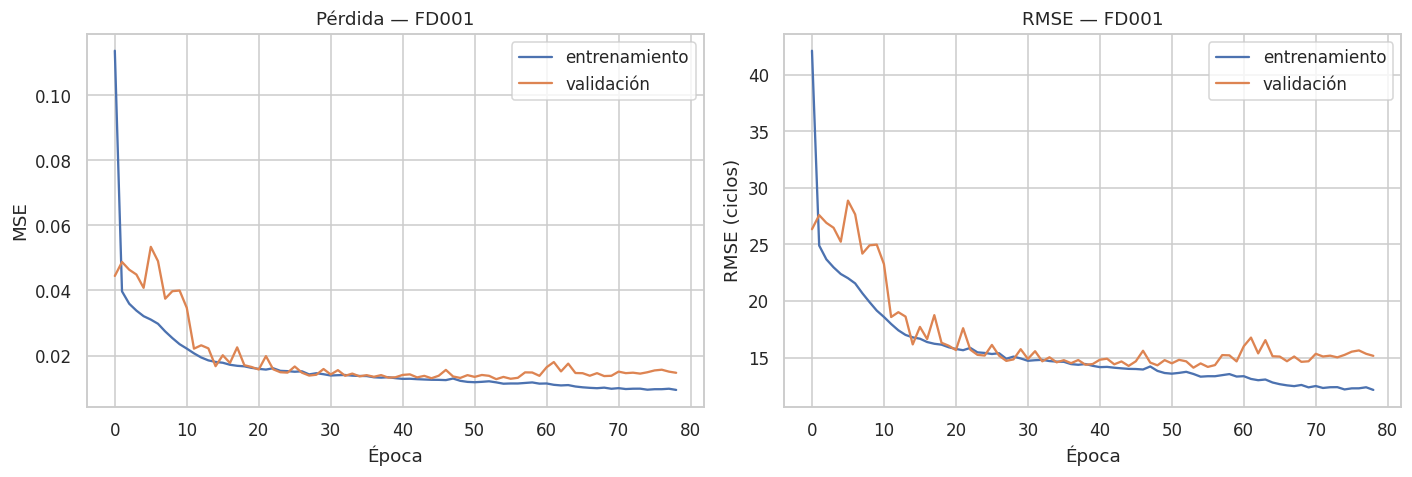

Épocas ejecutadas : 79
Mejor val_RMSE    : 0.113 ciclos
Brecha train-val  : -0.024 ciclos (sin señales claras de sobreajuste)


In [13]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(h["loss"], label="entrenamiento")
axes[0].plot(h["val_loss"], label="validación")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE")
axes[0].set_title(f"Pérdida — {SUBSET}"); axes[0].legend()

axes[1].plot(np.array(h["rmse"]) * RUL_CAP, label="entrenamiento")
axes[1].plot(np.array(h["val_rmse"]) * RUL_CAP, label="validación")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("RMSE (ciclos)")
axes[1].set_title(f"RMSE — {SUBSET}"); axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / f"curvas_aprendizaje_transformer_{SUBSET}.png", bbox_inches="tight")
plt.show()

print(f"Épocas ejecutadas : {len(h['loss'])}")
print(f"Mejor val_RMSE    : {min(h['val_rmse']):.3f} ciclos")

brecha = h["rmse"][-1] - h["val_rmse"][-1]
print(f"Brecha train-val  : {brecha:.3f} ciclos "
      f"({'posible sobreajuste' if brecha < -2 else 'sin señales claras de sobreajuste'})")

## 10. Evaluación sobre el conjunto de test

In [14]:
y_pred = model.predict(data.X_test, verbose=0).ravel() * RUL_CAP   # ← desescalado
y_pred = np.clip(y_pred, 0, RUL_CAP)

resultado = evaluate(data.y_test, y_pred, name=f"Transformer_{SUBSET}")
print(resultado.to_string())

modelo            Transformer_FD001
RMSE                         14.235
MAE                            10.9
NASA_Score                    311.1
sesgo_medio                   1.321
pct_retrasadas                 51.0


## 11. Diagnóstico visual de las predicciones

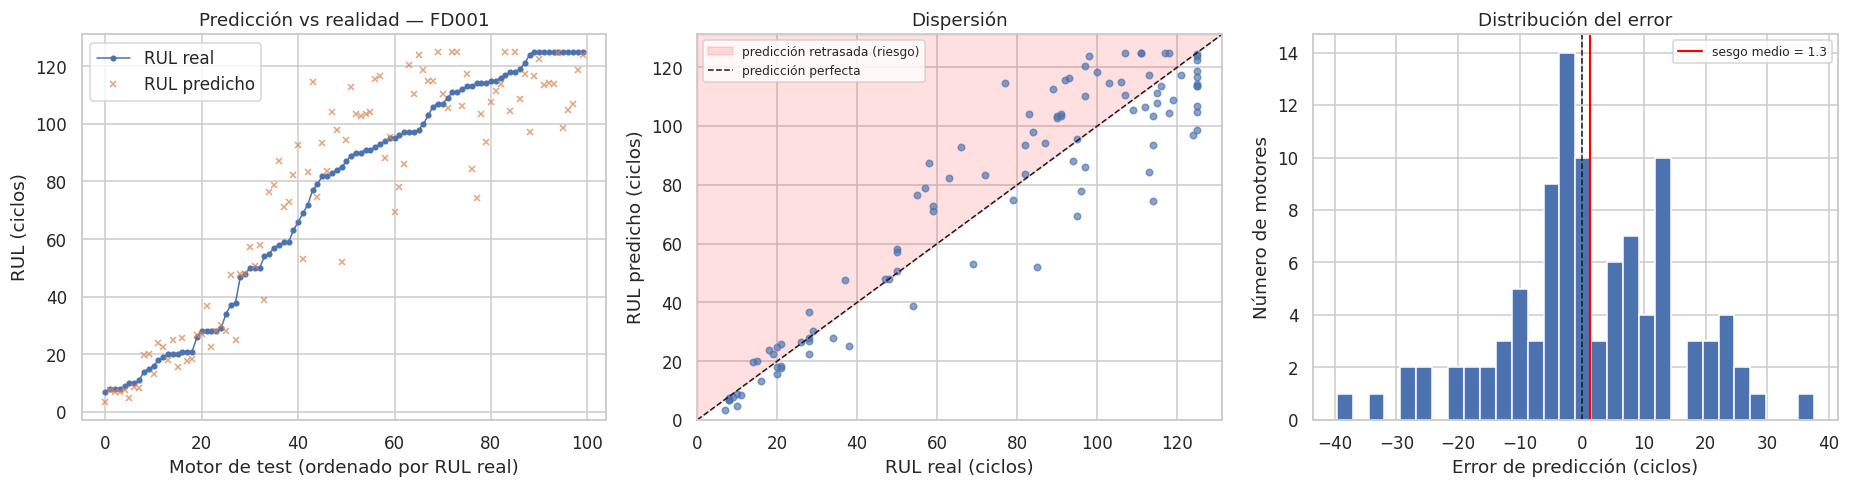

In [15]:
y_true = data.y_test
err = y_pred - y_true
order = np.argsort(y_true)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

axes[0].plot(y_true[order], "o-", ms=3, lw=1, label="RUL real")
axes[0].plot(y_pred[order], "x", ms=4, alpha=0.75, label="RUL predicho")
axes[0].set_xlabel("Motor de test (ordenado por RUL real)")
axes[0].set_ylabel("RUL (ciclos)")
axes[0].set_title(f"Predicción vs realidad — {SUBSET}"); axes[0].legend()

lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
axes[1].fill_between(lim, lim, lim[1], alpha=0.12, color="red",
                     label="predicción retrasada (riesgo)")
axes[1].scatter(y_true, y_pred, s=18, alpha=0.65)
axes[1].plot(lim, lim, "k--", lw=1, label="predicción perfecta")
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("RUL real (ciclos)"); axes[1].set_ylabel("RUL predicho (ciclos)")
axes[1].set_title("Dispersión"); axes[1].legend(fontsize=8)

axes[2].hist(err, bins=30, edgecolor="white")
axes[2].axvline(0, color="k", ls="--", lw=1)
axes[2].axvline(err.mean(), color="red", lw=1.4, label=f"sesgo medio = {err.mean():.1f}")
axes[2].set_xlabel("Error de predicción (ciclos)")
axes[2].set_ylabel("Número de motores")
axes[2].set_title("Distribución del error"); axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / f"predicciones_transformer_{SUBSET}.png", bbox_inches="tight")
plt.show()

## 12. Entrenamiento sobre los cuatro subsets

In [16]:
TODOS = ["FD001", "FD002", "FD003", "FD004"]
resultados = []

for nombre in TODOS:
    print(f"\n{'='*70}\n  {nombre}\n{'='*70}")
    s = load_subset(nombre, DATA_DIR)
    d = prepare(s, window=WINDOW, stride=STRIDE, rul_cap=RUL_CAP,
                val_frac=VAL_FRAC, use_settings=s.n_conditions > 1)
    print(d.report())

    m = build_transformer(window=d.window, n_features=d.n_features)
    m.fit(d.X_train, d.y_train,
          validation_data=(d.X_val, d.y_val),
          epochs=EPOCHS, batch_size=BATCH_SIZE,
          callbacks=default_callbacks(
              checkpoint_path=str(MODELS_DIR / f"transformer_{nombre}.keras"),
              patience=25, reduce_lr_patience=10),
          verbose=0)

    p = np.clip(m.predict(d.X_test, verbose=0).ravel(), 0, RUL_CAP)
    r = evaluate(d.y_test, p, name=f"Transformer_{nombre}")
    print(r.to_string())
    resultados.append(r)

tabla = comparison_table(resultados)
(PROJECT_DIR / "reports").mkdir(parents=True, exist_ok=True)
tabla.to_csv(PROJECT_DIR / "reports" / "resultados_transformer.csv")
tabla


  FD001
[FD001] ventana=30  features=15  cap RUL=125
  sensores descartados : 6
  X_train : (14381, 30, 15)
  X_val   : (3350, 30, 15)
  X_test  : (100, 30, 15)

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 54: early stopping
Restoring model weights from the end of the best epoch: 29.
modelo            Transformer_FD001
RMSE                         14.874
MAE                          11.309
NASA_Score                    441.7
sesgo_medio                   5.121
pct_retrasadas                 61.0

  FD002
[FD002] ventana=30  features=20  cap RUL=125
  sensores descartados : 4
  X_train : (36545, 30, 20)
  X_val   : (9674, 30, 20)
  X_test  : (259, 30, 20)

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 38: early stopping
Restoring model weights from the end o

modelo            Transformer_FD002
RMSE                         14.707
MAE                          10.883
NASA_Score                   1239.7
sesgo_medio                   0.307
pct_retrasadas                 44.0

  FD003
[FD003] ventana=30  features=16  cap RUL=125
  sensores descartados : 5
  X_train : (17156, 30, 16)
  X_val   : (4664, 30, 16)
  X_test  : (100, 30, 16)

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 58: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 68: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 73: early stopping
Restoring model weights from the end of the best epoch: 48.
modelo            Transformer_FD003
RMSE                         12.629
MAE                           8.725
NASA_Score                    311.1
sesgo_medio                   3.479
pct_retrasadas                 54.0

  FD004
[

modelo            Transformer_FD004
RMSE                          15.69
MAE                          11.049
NASA_Score                   1381.3
sesgo_medio                  -0.206
pct_retrasadas                 42.3


,RMSE,MAE,NASA_Score,sesgo_medio,pct_retrasadas
modelo,,,,,
Transformer_FD003,12.629,8.725,311.1,3.479,54.0
Transformer_FD002,14.707,10.883,1239.7,0.307,44.0
Transformer_FD001,14.874,11.309,441.7,5.121,61.0
Transformer_FD004,15.690,11.049,1381.3,-0.206,42.3


## 13. Robustez frente a la semilla aleatoria

Esta sección es especialmente relevante aquí. Los Transformer presentan mayor variabilidad entre
inicializaciones que las arquitecturas recurrentes, de modo que una única ejecución resulta poco
informativa.

In [18]:
SEMILLAS = [23, 42, 2024]
repeticiones = []

for semilla in SEMILLAS:
    m = build_transformer(window=data.window, n_features=data.n_features, seed=semilla)
    m.fit(data.X_train, data.y_train / RUL_CAP,
          validation_data=(data.X_val, data.y_val / RUL_CAP),
          epochs=EPOCHS, batch_size=BATCH_SIZE,
          callbacks=default_callbacks(patience=25, reduce_lr_patience=10),
          verbose=0)
    p = np.clip(m.predict(data.X_test, verbose=0).ravel() * RUL_CAP, 0, RUL_CAP)
    r = evaluate(data.y_test, p, name=f"semilla_{semilla}")
    repeticiones.append(r)
    print(f"semilla {semilla:>5} -> RMSE {r['RMSE']:.3f}   NASA {r['NASA_Score']:.1f}")

rep = pd.DataFrame(repeticiones).set_index("modelo")
print(f"\nRMSE       : {rep['RMSE'].mean():.2f} ± {rep['RMSE'].std():.2f}")
print(f"NASA Score : {rep['NASA_Score'].mean():.1f} ± {rep['NASA_Score'].std():.1f}")


Epoch 64: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 74: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 79: early stopping
Restoring model weights from the end of the best epoch: 54.
semilla    23 -> RMSE 14.235   NASA 311.1

Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 76: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 86: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 91: early stopping
Restoring model weights from the end of the best epoch: 66.
semilla    42 -> RMSE 13.880   NASA 353.5

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 51: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 61: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 71: ReduceLROnPlateau reducing learning

## 14. Comparativa final de las tres arquitecturas

Esta sección consolida los resultados de los tres notebooks y produce las tablas y figuras
principales del apartado de resultados de la memoria.

In [19]:
rutas = {
    "LSTM":          PROJECT_DIR / "reports" / "resultados_lstm.csv",
    "CNN-LSTM-Attn": PROJECT_DIR / "reports" / "resultados_cnnlstm.csv",
    "Transformer":   PROJECT_DIR / "reports" / "resultados_transformer.csv",
}

faltan = [k for k, v in rutas.items() if not v.exists()]
if faltan:
    print(f"Faltan resultados de: {', '.join(faltan)}. Ejecuta antes esos notebooks.")
else:
    frames = {}
    for modelo, ruta in rutas.items():
        df = pd.read_csv(ruta, index_col=0)
        df.index = [i.split("_")[-1] for i in df.index]
        frames[modelo] = df

    rmse_tab  = pd.DataFrame({m: f["RMSE"] for m, f in frames.items()}).sort_index()
    nasa_tab  = pd.DataFrame({m: f["NASA_Score"] for m, f in frames.items()}).sort_index()
    mae_tab   = pd.DataFrame({m: f["MAE"] for m, f in frames.items()}).sort_index()

    print("RMSE por subset y arquitectura (ciclos)")
    print(rmse_tab.round(3).to_string())
    print(f"\nMejor arquitectura por subset: "
          f"{rmse_tab.idxmin(axis=1).to_dict()}")

    rmse_tab.to_csv(PROJECT_DIR / "reports" / "comparativa_final_rmse.csv")
    display(rmse_tab.round(3))

RMSE por subset y arquitectura (ciclos)
         LSTM  CNN-LSTM-Attn  Transformer
FD001  13.923         14.326       14.874
FD002  14.434         15.145       14.707
FD003  13.423         12.868       12.629
FD004  15.425         17.071       15.690

Mejor arquitectura por subset: {'FD001': 'LSTM', 'FD002': 'LSTM', 'FD003': 'Transformer', 'FD004': 'LSTM'}


,LSTM,CNN-LSTM-Attn,Transformer
FD001,13.923,14.326,14.874
FD002,14.434,15.145,14.707
FD003,13.423,12.868,12.629
FD004,15.425,17.071,15.690


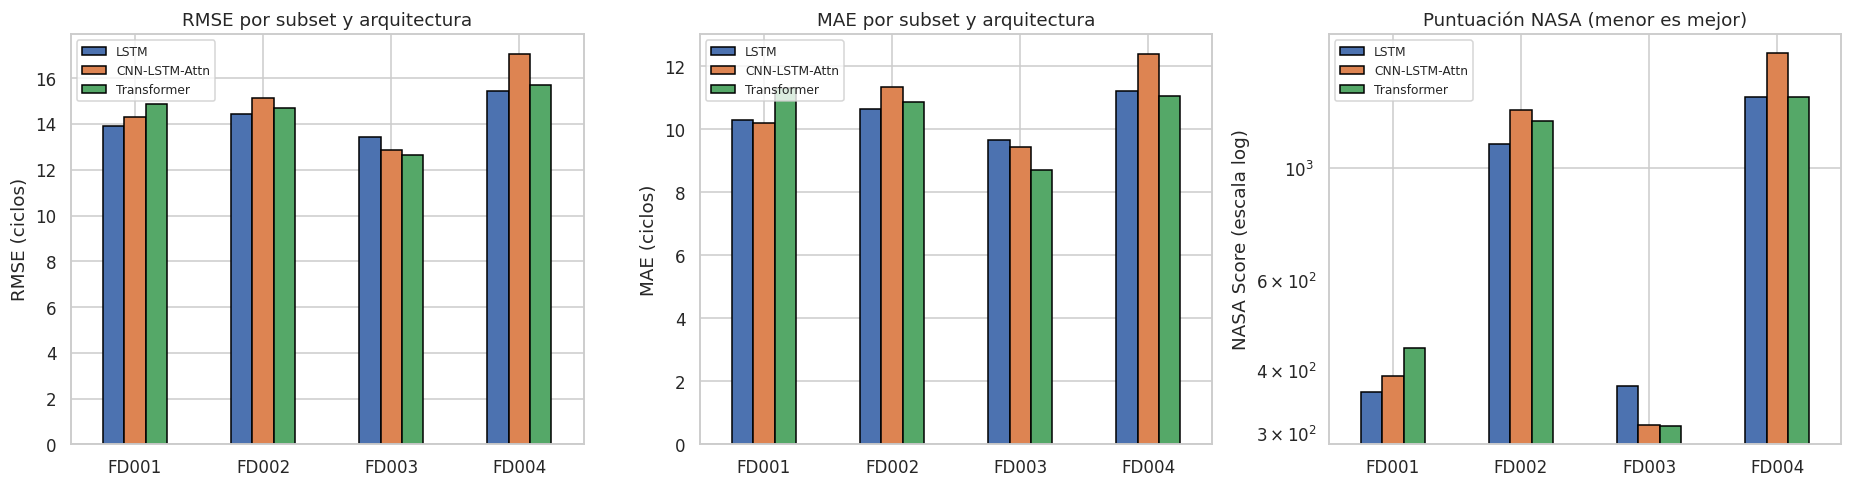

In [20]:
if not faltan:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

    rmse_tab.plot(kind="bar", ax=axes[0], edgecolor="black")
    axes[0].set_ylabel("RMSE (ciclos)"); axes[0].set_xlabel("")
    axes[0].set_title("RMSE por subset y arquitectura")
    axes[0].tick_params(axis="x", rotation=0); axes[0].legend(fontsize=8)

    mae_tab.plot(kind="bar", ax=axes[1], edgecolor="black")
    axes[1].set_ylabel("MAE (ciclos)"); axes[1].set_xlabel("")
    axes[1].set_title("MAE por subset y arquitectura")
    axes[1].tick_params(axis="x", rotation=0); axes[1].legend(fontsize=8)

    nasa_tab.plot(kind="bar", ax=axes[2], edgecolor="black", logy=True)
    axes[2].set_ylabel("NASA Score (escala log)"); axes[2].set_xlabel("")
    axes[2].set_title("Puntuación NASA (menor es mejor)")
    axes[2].tick_params(axis="x", rotation=0); axes[2].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "comparativa_final_tres_modelos.png", bbox_inches="tight")
    plt.show()

In [21]:
# Descomposición factorial: efecto de cada factor sobre el RMSE
if not faltan:
    efecto = pd.DataFrame({
        "efecto_condiciones_operativas": (
            (rmse_tab.loc["FD002"] - rmse_tab.loc["FD001"]) +
            (rmse_tab.loc["FD004"] - rmse_tab.loc["FD003"])) / 2,
        "efecto_modos_de_fallo": (
            (rmse_tab.loc["FD003"] - rmse_tab.loc["FD001"]) +
            (rmse_tab.loc["FD004"] - rmse_tab.loc["FD002"])) / 2,
    }).round(3)

    print("Incremento medio del RMSE atribuible a cada factor (ciclos)\n")
    print(efecto.to_string())
    print("\nLectura: cuánto empeora cada arquitectura al añadir cada factor de dificultad.")
    print("Una arquitectura robusta muestra incrementos menores.")

Incremento medio del RMSE atribuible a cada factor (ciclos)

               efecto_condiciones_operativas  efecto_modos_de_fallo
LSTM                                   1.256                  0.246
CNN-LSTM-Attn                          2.511                  0.234
Transformer                            1.447                 -0.631

Lectura: cuánto empeora cada arquitectura al añadir cada factor de dificultad.
Una arquitectura robusta muestra incrementos menores.
